In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("Wholesale customers data.csv")
df.head(5)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


--- Data Shape and Missing Values ---
(440, 8)
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

--- Descriptive Statistics ---
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delica

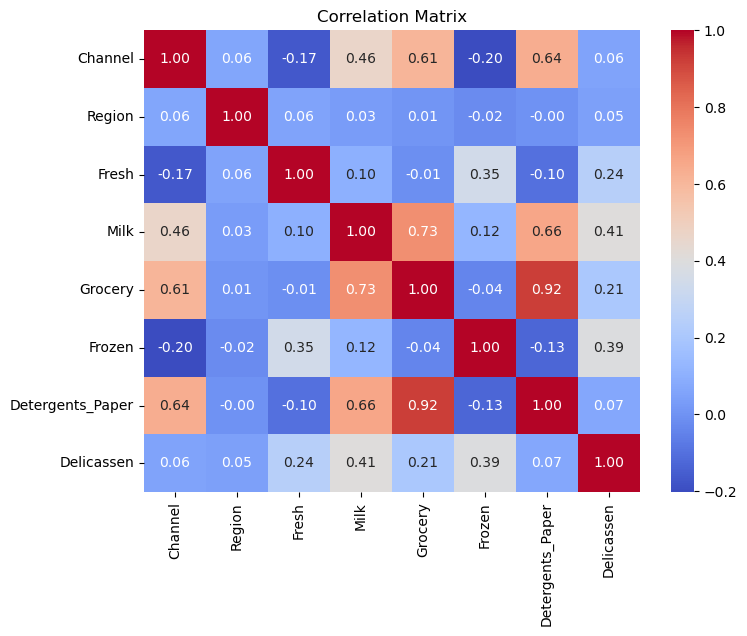

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' contains your dataframe
print("--- Data Shape and Missing Values ---")
print(df.shape)
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
print(df.describe())

# Value counts for categorical targets
print("\n--- Channel Distribution ---")
print(df['Channel'].value_counts())

# Correlation Matrix Visual
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop categorical features to isolate spending data
X_pca = df.drop(columns=['Channel', 'Region'])

# Scale features
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA(n_components=2)
X_components = pca.fit_transform(X_pca_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained by 2 components: {sum(pca.explained_variance_ratio_):.2%}")


Explained Variance Ratio: [0.44082893 0.283764  ]
Total Variance Explained by 2 components: 72.46%


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fit K-Means on the scaled features
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca_scaled)

print(f"K-Means Silhouette Score (k=3): {silhouette_score(X_pca_scaled, cluster_labels):.3f}")


K-Means Silhouette Score (k=3): 0.548


c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [8]:
from sklearn.model_selection import train_test_split

# Setup for Classification Models (Predicting 'Channel': 1 vs 2)
X_cls = df.drop(columns=['Channel'])
y_cls = df['Channel']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Scale classification datasets
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# Setup for Regression Models (Predicting continuous variable 'Grocery')
X_reg = df.drop(columns=['Grocery'])
y_reg = df['Grocery']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize Models
models_cls = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42)
}

# Dictionary to hold accuracy values
cls_results = {}

# Train and Evaluate
for name, model in models_cls.items():
    # Linear models and SVM require feature scaling
    if name in ["Logistic Regression", "Support Vector Machine"]:
        model.fit(X_train_c_scaled, y_train_c)
        preds = model.predict(X_test_c_scaled)
    else:
        model.fit(X_train_c, y_train_c)
        preds = model.predict(X_test_c)
    
    acc = accuracy_score(y_test_c, preds)
    cls_results[name] = acc
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test_c, preds))


=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

           1       0.92      0.86      0.89        65
           2       0.67      0.78      0.72        23

    accuracy                           0.84        88
   macro avg       0.79      0.82      0.80        88
weighted avg       0.85      0.84      0.84        88

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           1       0.97      0.89      0.93        65
           2       0.75      0.91      0.82        23

    accuracy                           0.90        88
   macro avg       0.86      0.90      0.88        88
weighted avg       0.91      0.90      0.90        88

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           1       0.95      0.94      0.95        65
           2       0.83      0.87      0.85        23

    accuracy                           0.92 

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
reg_preds = lin_reg.predict(X_test_r)

r2 = r2_score(y_test_r, reg_preds)
rmse = np.sqrt(mean_squared_error(y_test_r, reg_preds))

print("=== Linear Regression Metrics ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")


=== Linear Regression Metrics ===
R² Score: 0.8113
RMSE: 2974.95


c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

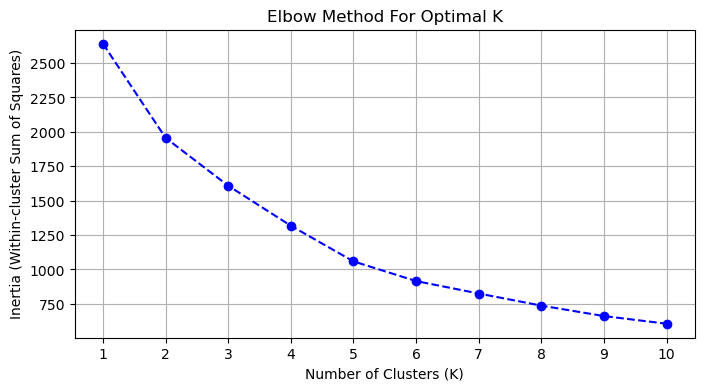

c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


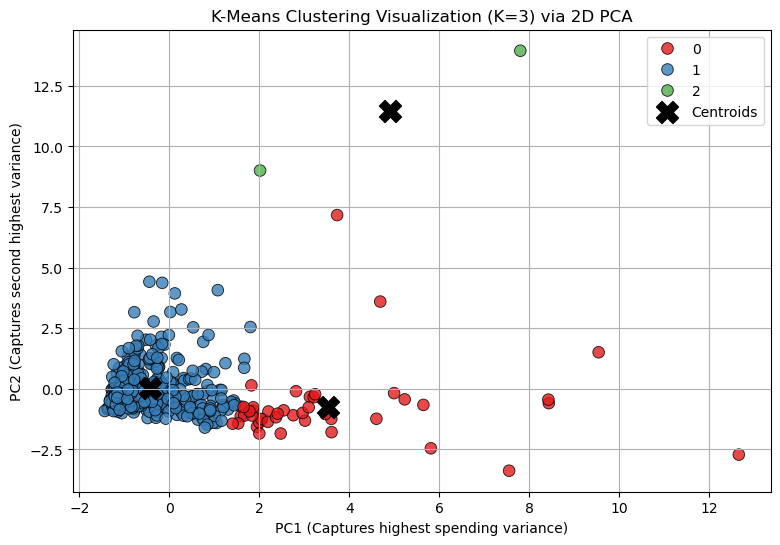

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. Prepare and Scale the Data ---
# Drop categorical columns to focus only on spending patterns
X = df.drop(columns=['Channel', 'Region'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. The Elbow Method (Plot to find optimal clusters) ---
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method For Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# --- 3. Fit K-Means with Optimal K (e.g., K=3) ---
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster assignments back to original dataframe for analysis
df['Cluster'] = cluster_labels

# --- 4. PCA for 2D Cluster Visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Cluster'] = cluster_labels

# Plot the clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='Cluster', 
    palette='Set1', 
    data=df_pca, 
    s=70, 
    alpha=0.8,
    edgecolor='k'
)

# Plot the centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1], 
    s=250, 
    marker='X', 
    c='black', 
    label='Centroids'
)

plt.title(f'K-Means Clustering Visualization (K={optimal_k}) via 2D PCA')
plt.xlabel('PC1 (Captures highest spending variance)')
plt.ylabel('PC2 (Captures second highest variance)')
plt.legend()
plt.grid(True)
plt.show()
